# 05 — Build Model Inputs

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

Writes the matrices that Part II actually uses from this notebook: `en_only` (DFM-EN) and `pls_only` (DFM-PLS). Also writes a ≥3/4 vote matrix (`core`) used to tune XGBoost. Publication lags are enforced in notebook 06, not by dropping series here.

The thesis does not identify a unique indicator set. The DFM comparison is EN vs block-balanced vs PLS vs frozen ifoCAST. Block-balanced and ifoCAST are built in the DFM scripts, not in this notebook.

| Matrix | Rule | Role in the thesis |
|---|---|---|
| `en_only` | Capped elastic net | DFM-EN |
| `pls_only` | PLS+VIP top 30 | DFM-PLS |
| `core` | ≥3 of EN, EN-smoothed, PLS, fixed-*k* | XGBoost hyperparameter tuning only |

A matrix-level intra-quarter lag gate would drop PLS’s lag-2 selections at M1/M2 and drive Jaccard overlap to zero. That is an artefact, not a finding.


## 1. Setup

`MIN_VOTES = 3`. Inputs are the EN, EN-smoothed, PLS, and fixed-*k* = 30 matrices from notebooks 03–04, plus category metadata. The fourth voter is the Bai and Ng path, not the block-balanced *k* = 20 set.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.selection.core_utils import load_monthly_panel
from german_gdp_nowcasting.selection.dfm_input_builder import build_dfm_input_sets

MIN_VOTES = 3
_tp.SELECTION_DIR.mkdir(parents=True, exist_ok=True)
print(f'Repo    : {_tp.REPO_ROOT}')
print(f'Dataset : {_tp.DATASET_XLSX}')
print(f'Data    : {_tp.DATA}')
print(f'Outputs : {_tp.OUTPUTS}')


Repo    : /Users/niki/M.Sc Thesis/german-gdp-nowcasting
Dataset : /Users/niki/M.Sc Thesis/Dataset/ifoCAST_DATA.xlsx
Data    : /Users/niki/M.Sc Thesis/Project_files/data
Outputs : /Users/niki/M.Sc Thesis/Project_files/outputs


## 2. Load inputs

Loads the four binary matrices from notebooks 03–04 and the enriched indicator dictionary. The matrices have the same origin index and column order.

PLS and fixed-*k* contain 30 series at every origin. EN is data-driven and capped at 60 in the thesis specification.


In [2]:
en_raw      = pd.read_csv(_tp.SELECTION_MATRIX_CSV,        index_col='forecast_origin').astype(int)
en_smoothed = pd.read_csv(_tp.EN_SMOOTHED_MATRIX_CSV,      index_col='forecast_origin').astype(int)
pls_matrix  = pd.read_csv(_tp.PLS_MATRIX_CSV,              index_col='forecast_origin').astype(int)
fixedk      = pd.read_csv(_tp.FIXEDK_MATRIX_CSV,           index_col='forecast_origin').astype(int)
matrices = {
    'EN raw':      en_raw,
    'EN smoothed': en_smoothed,
    'PLS':         pls_matrix,
    'fixed-k (k=30)':     fixedk,
}
for label, matrix in matrices.items():
    print(
        f'{label:16s}: {matrix.shape[0]} origins x {matrix.shape[1]} series'
        f' | mean selected/origin = {matrix.sum(axis=1).mean():.1f}'
    )
meta = pd.read_csv(
    _tp.DATA_DICT_ENRICHED_CSV,
    usecols=['id', 'name', 'category'],
).set_index('id')
X_monthly = load_monthly_panel(_tp.PANEL_TRANSFORMED_CSV)


EN raw          : 180 origins x 585 series | mean selected/origin = 51.5
EN smoothed     : 180 origins x 585 series | mean selected/origin = 62.3
PLS             : 180 origins x 585 series | mean selected/origin = 30.0
fixed-k (k=30)  : 180 origins x 585 series | mean selected/origin = 30.0


## 3. Build the matrices

`build_core_matrix` counts, at each origin, how many of the four loaded methods selected series *j*, and keeps *j* if that count is at least 3. That vote is an XGBoost convenience, not a claim that the methods recover one German core (Part I rank correlations 0.28–0.43).

`en_only` and `pls_only` are the corresponding raw matrices. No publication-lag filter is applied.


In [3]:
sets = build_dfm_input_sets(
    matrices=matrices,
    meta=meta,
    min_votes=MIN_VOTES,
    en_label='EN raw',
    pls_label='PLS',
)
rate_table_diag = sets.pop('_rate_table_diagnostic')
print('Full-sample rate table (diagnostic only):')
print(
    rate_table_diag[['mean_across_methods', 'category']]
    .sort_values('mean_across_methods', ascending=False)
    .head(20)
    .to_string()
)
print('\nSelected count per origin (mean / min / max):')
for name, matrix in sets.items():
    counts = matrix.sum(axis=1)
    print(
        f'  {name:9s}: mean={counts.mean():5.1f}'
        f' min={int(counts.min()):3d} max={int(counts.max()):3d}'
    )
if sets['en_only'].sum(axis=1).max() > 60:
    raise ValueError('The EN input matrix exceeds the configured cap of 60 series.')


Full-sample rate table (diagnostic only):
            mean_across_methods    category
detrad3415             0.979167    Turnover
deprod1404             0.958333  Production
deprod1989             0.900000  Production
detrad1360             0.850000    Turnover
detrad3877             0.841667    Turnover
deprod4738             0.816667      Orders
detrad3364             0.808333    Turnover
detrad1954             0.787500    Turnover
detrad3518             0.770833    Turnover
detrad0692             0.766667       Trade
deprod1984             0.762500  Production
deprod3790             0.737500  Production
detrad4770             0.725000    Turnover
deprod0194             0.716667  Production
deprod0190             0.695833  Production
detrad3857             0.687500    Turnover
detrad1879             0.683333    Turnover
deprod0191             0.679167  Production
detrad4750             0.654167    Turnover
detrad4789             0.620833    Turnover

Selected count per origin (mean /

## 4. Save

Writes `core_selection_matrix.csv`, `en_only_selection_matrix.csv`, and `pls_only_selection_matrix.csv` to the configured indicator-selection output directory.

Notebook 06 loads `en_only` as DFM-EN. `pls_only` is the sensitivity set. `core` is used for XGBoost tuning and is not a DFM headline.


In [4]:
paths_out = {
    'core':     _tp.CORE_MATRIX_CSV,
    'en_only':  _tp.EN_ONLY_MATRIX_CSV,
    'pls_only': _tp.PLS_ONLY_MATRIX_CSV,
}
for key, path in paths_out.items():
    sets[key].to_csv(path)
    try:
        shown = path.relative_to(_tp.REPO_ROOT)
    except ValueError:
        shown = path
    print(f'  {key:9s} -> {shown}')


  core      -> /Users/niki/M.Sc Thesis/Project_files/outputs/indicator_selection/dfm_input_sets/core_selection_matrix.csv
  en_only   -> /Users/niki/M.Sc Thesis/Project_files/outputs/indicator_selection/dfm_input_sets/en_only_selection_matrix.csv
  pls_only  -> /Users/niki/M.Sc Thesis/Project_files/outputs/indicator_selection/dfm_input_sets/pls_only_selection_matrix.csv


## 5. Diagnostics

The EN set contains 12–60 series (mean 51.5) and PLS contains 30 at every origin.

Origin-by-origin Jaccard among `core`, `en_only`, and `pls_only` describes these three files. It is not the thesis agreement statistic (Spearman correlations of full-window weights, 0.28–0.43). High overlap between `core` and PLS is partly mechanical because PLS is one of the four voters.

The PC variance share at the last origin checks that the vote set has common-factor structure. The DFM uses two factors on `en_only`, not on `core`.


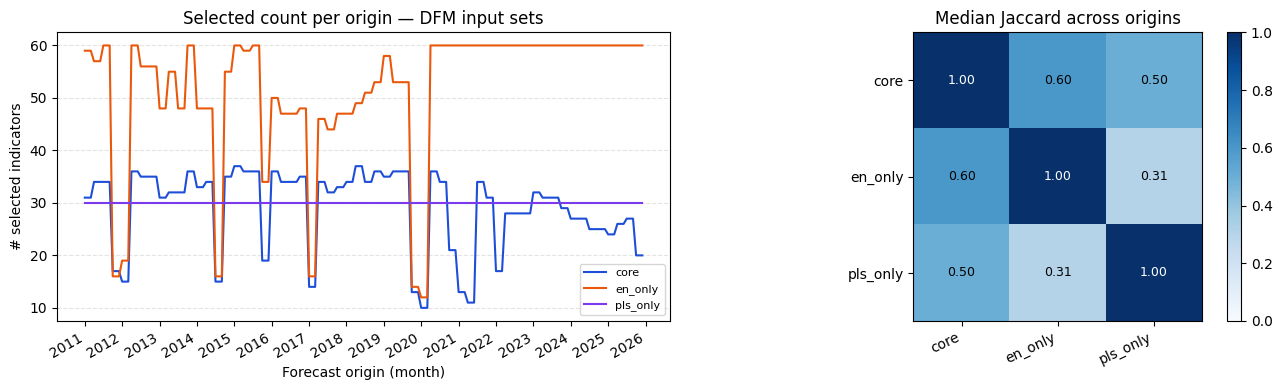

In [5]:
import matplotlib.dates as mdates
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
_x = pd.to_datetime(sets['core'].index)
colors = {'core': '#1d4ed8', 'en_only': '#ea580c', 'pls_only': '#7c3aed'}
for key, m in sets.items():
    ax.plot(_x, m.sum(axis=1).values, label=key, lw=1.5, color=colors[key])
ax.set_xlabel('Forecast origin (month)')
ax.set_ylabel('# selected indicators')
ax.set_title('Selected count per origin — DFM input sets')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax = axes[1]
keys = list(sets.keys())
J = np.zeros((len(keys), len(keys)))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        a = sets[ki].astype(bool)
        b = sets[kj].reindex(index=a.index, columns=a.columns, fill_value=0).astype(bool)
        inter = (a & b).sum(axis=1)
        union = (a | b).sum(axis=1).replace(0, np.nan)
        J[i, j] = (inter / union).median()
im = ax.imshow(J, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys, rotation=25, ha='right')
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys)
ax.set_title('Median Jaccard across origins')
for i in range(len(keys)):
    for j in range(len(keys)):
        ax.text(j, i, f'{J[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if J[i, j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
plt.tight_layout(); plt.show()

In [6]:
# PC variance share for the core set at the last origin
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
last_origin = sets['core'].index[-1]
sel = sets['core'].columns[sets['core'].loc[last_origin].astype(bool)]
X_sel = X_monthly.loc[:, sel.intersection(X_monthly.columns)].copy()
X_sel = X_sel.loc[X_sel.notna().any(axis=1)]
X_arr = StandardScaler().fit_transform(SimpleImputer(strategy='mean').fit_transform(X_sel.values))
pca = PCA(n_components=min(5, X_arr.shape[1])).fit(X_arr)
var_share = pca.explained_variance_ratio_.cumsum()
print(f'Core set at {last_origin}: N = {X_sel.shape[1]} series, T = {X_sel.shape[0]} months')
for k, v in enumerate(var_share, start=1):
    print(f'  cumulative variance of first {k} PCs: {v:.3f}')

Core set at 2025-12: N = 20 series, T = 419 months
  cumulative variance of first 1 PCs: 0.424
  cumulative variance of first 2 PCs: 0.511
  cumulative variance of first 3 PCs: 0.574
  cumulative variance of first 4 PCs: 0.633
  cumulative variance of first 5 PCs: 0.686


## 6. Next

`06_dfm_nowcasting.ipynb` estimates the mixed-frequency DFM on `en_only`. Block-balanced, ifoCAST, the equal-weight combination, DFM-TVP, DFM-SV, MLP-Factor and the AR variants are produced by the scripts listed at the end of that notebook.

Holding the DFM fixed, full-sample accuracy differences among EN, block-balanced, PLS and ifoCAST do not reject equal accuracy. After 2022 the average M1-to-M3 RMSFE profile inverts for every reported DFM.
